# 🌿 Plant Disease Detection — Complete Project Documentation

**AI/ML Internship Project | Task 8: Documentation**

---

## Project Overview

This project builds an image classification system to detect plant diseases
from leaf photographs using deep learning. We trained and compared 3 models
on the PlantVillage dataset and deployed the best model as a REST API.

| Item | Detail |
|------|--------|
| **Dataset** | PlantVillage (54,305 images, 39 classes) |
| **Best Model** | MobileNetV2 (Transfer Learning) |
| **Best Accuracy** | 67.88% (on sampled dataset) |
| **Deployment** | FastAPI REST API |
| **Tools** | Python, TensorFlow, Scikit-learn, FastAPI |

---

## Table of Contents
1. Setup & Imports
2. Dataset Overview
3. Feature Engineering & Preprocessing
4. Model Training
5. Model Evaluation
6. Hyperparameter Tuning
7. Deployment Summary
8. Key Findings & Conclusions

In [1]:
import os
os.chdir(r"C:\Users\User\plantvillage\plantvillage dataset\color")
print(f"Working directory set to: {os.getcwd()}")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Config
DATASET_PATH = r"C:\Users\User\plantvillage\plantvillage dataset\color"
IMG_SIZE     = (128, 128)
BATCH_SIZE   = 32
SEED         = 42

with open("class_names.json") as f:
    class_names = json.load(f)
NUM_CLASSES = len(class_names)

print(f"TensorFlow version : {tf.__version__}")
print(f"Classes            : {NUM_CLASSES}")
print(f"Dataset path       : {DATASET_PATH}")
print("Setup complete ✓")

Working directory set to: C:\Users\User\plantvillage\plantvillage dataset\color
TensorFlow version : 2.21.0
Classes            : 39
Dataset path       : C:\Users\User\plantvillage\plantvillage dataset\color
Setup complete ✓


---
## 1. Dataset Overview

The **PlantVillage dataset** contains 54,305 labeled leaf images across
39 classes (38 disease/healthy combinations across 14 crop species).

**Key findings from EDA (Task 2):**
- All images are uniform: **256×256 RGB JPEGs**
- Zero corrupt files found
- Dataset split: **~70% diseased, ~30% healthy**
- Most represented crop: **Tomato** (18,159 images, 10 disease types)
- Least represented: **Raspberry** (~370 images)

In [2]:
# Load saved EDA results
df = pd.read_csv(r"C:\Users\User\plantvillage\plantvillage dataset\color\dataset_summary.csv")

print("Dataset Summary")
print("="*50)
print(f"Total images  : {df['count'].sum():,}")
print(f"Total classes : {len(df)}")
print(f"Healthy       : {df['is_healthy'].sum()} classes")
print(f"Diseased      : {(~df['is_healthy']).sum()} classes")
print(f"Unique crops  : {df['crop'].nunique()}")
print()

print("Top 10 classes by image count:")
print(df[['crop','disease','count']].head(10).to_string(index=False))

Dataset Summary
Total images  : 54,303
Total classes : 38
Healthy       : 12 classes
Diseased      : 26 classes
Unique crops  : 14

Top 10 classes by image count:
   crop                              disease  count
 Orange      Haunglongbing (Citrus greening)   5507
 Tomato        Tomato Yellow Leaf Curl Virus   5357
Soybean                              healthy   5090
  Peach                       Bacterial spot   2297
 Tomato                       Bacterial spot   2127
 Tomato                          Late blight   1908
 Squash                       Powdery mildew   1835
 Tomato                   Septoria leaf spot   1771
 Tomato Spider mites Two-spotted spider mite   1676
  Apple                              healthy   1645


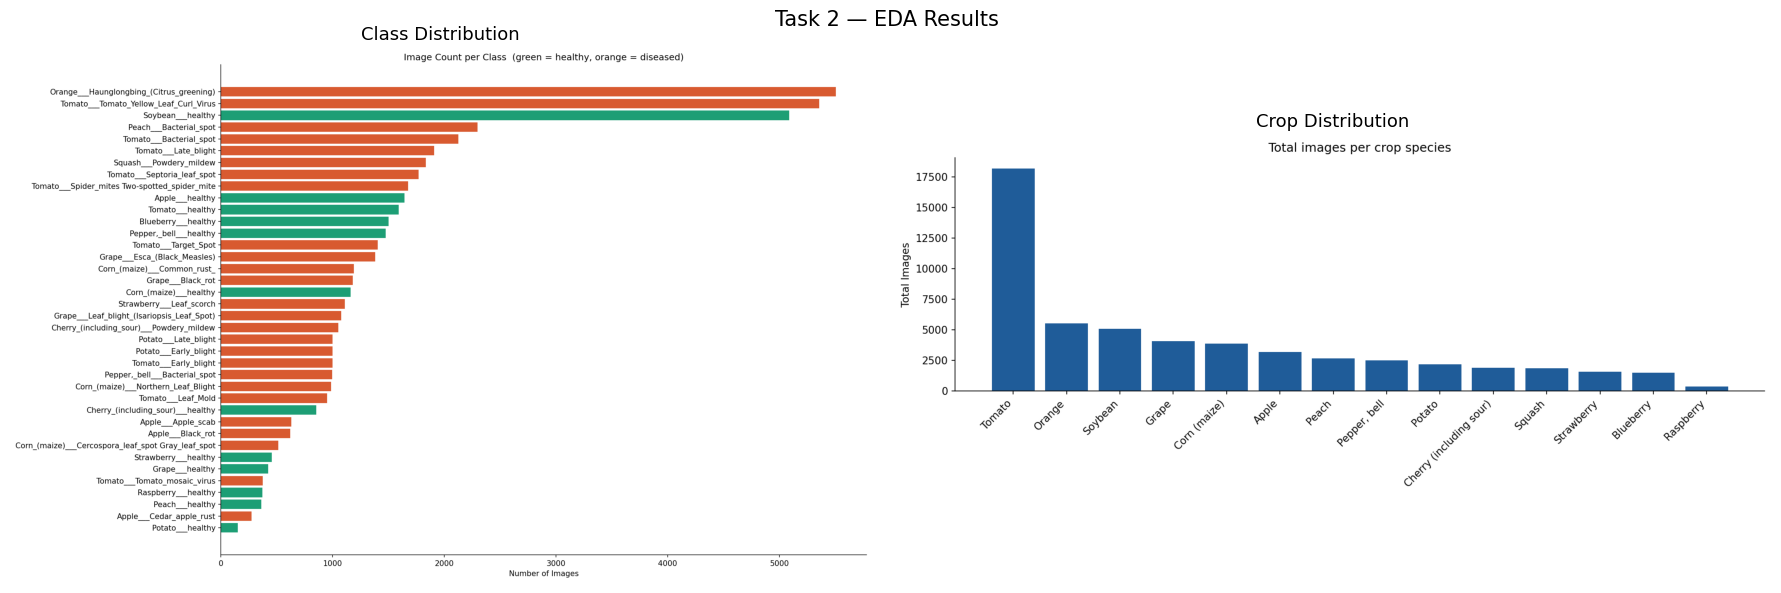

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Class distribution
img1 = mpimg.imread("class_distribution.png")
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title("Class Distribution", fontsize=13)

# Sample images
img2 = mpimg.imread("crop_distribution.png")
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("Crop Distribution", fontsize=13)

plt.suptitle("Task 2 — EDA Results", fontsize=15)
plt.tight_layout()
plt.show()

---
## 2. Feature Engineering & Preprocessing

**Pipeline built in Task 3:**

| Step | Detail |
|------|--------|
| Resize | 256×256 → 128×128 (memory optimization) |
| Normalize | Pixel values [0,255] → [0.0,1.0] |
| Split | 80% train / 10% val / 10% test |
| Augmentation | Random flip, rotate, zoom, brightness, contrast |
| Optimization | Cache + prefetch (AUTOTUNE) |

Augmentation is applied **only during training** to artificially increase
dataset diversity and reduce overfitting.

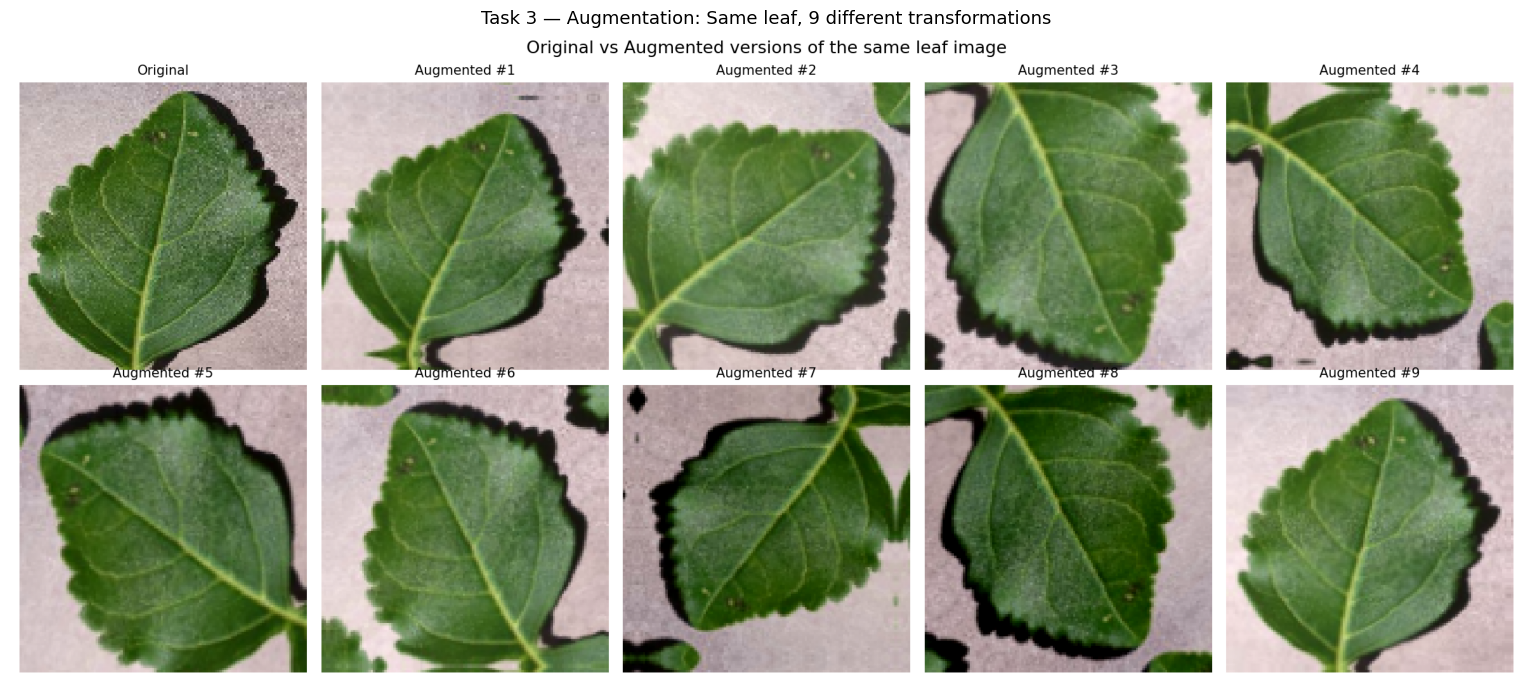

In [4]:
img = mpimg.imread("augmentation_preview.png")
plt.figure(figsize=(16, 7))
plt.imshow(img)
plt.axis('off')
plt.title("Task 3 — Augmentation: Same leaf, 9 different transformations",
          fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Model Training & Architecture

**Three models were trained and compared (Task 4):**

### Model 1: Logistic Regression (Baseline)
- Flattens each 128×128×3 image into a 49,152-feature vector
- Trained on a sampled subset (memory constraints)
- Purpose: establish a lower-bound baseline

### Model 2: Custom CNN
- 4 convolutional blocks (32→64→128→256 filters)
- BatchNormalization + MaxPooling after each block
- GlobalAveragePooling → Dense(256) → Dropout(0.4) → Softmax
- Trained from scratch on sampled data

### Model 3: MobileNetV2 (Transfer Learning) ⭐
- Pre-trained on ImageNet (1.4M images, 1000 classes)
- Base model frozen → only top layers trained
- GlobalAveragePooling → Dense(256) → Dropout(0.3) → Softmax
- Best performing model

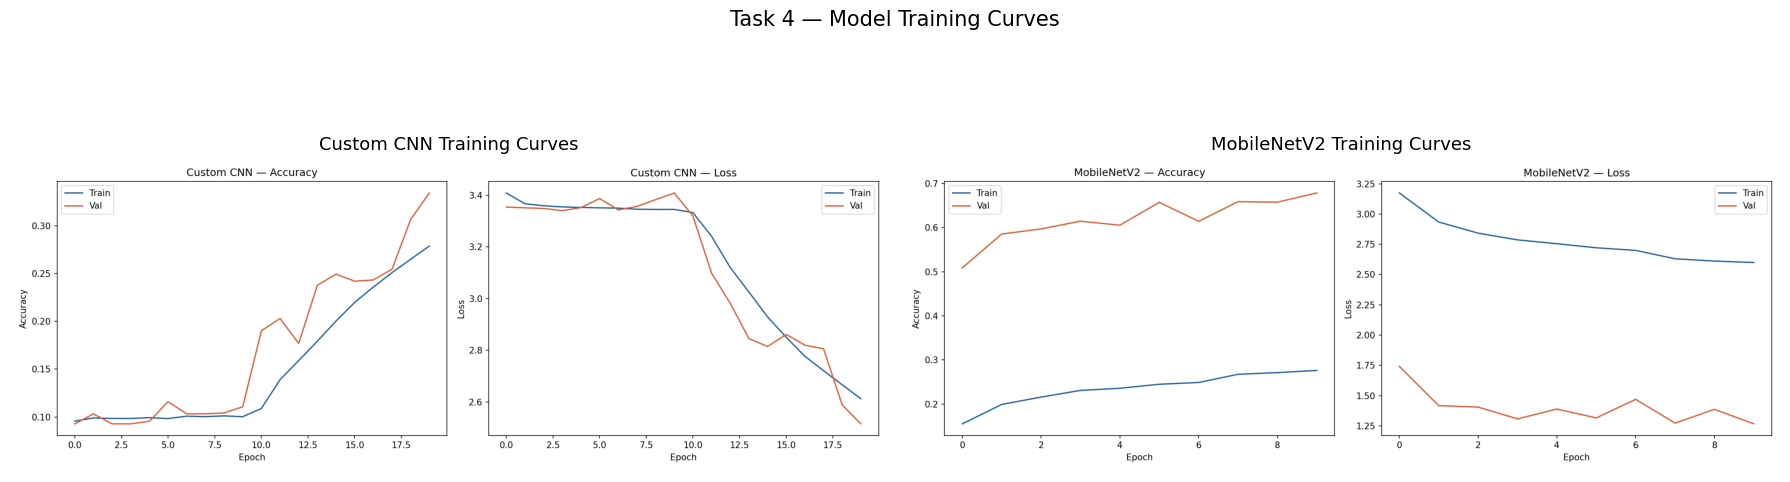

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

img1 = mpimg.imread("Custom_CNN_curves.png")
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title("Custom CNN Training Curves", fontsize=13)

img2 = mpimg.imread("MobileNetV2_curves.png")
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("MobileNetV2 Training Curves", fontsize=13)

plt.suptitle("Task 4 — Model Training Curves", fontsize=15)
plt.tight_layout()
plt.show()

---
## 4. Model Evaluation & Comparison

All models evaluated on the held-out test set using:
- **Accuracy** — overall correct predictions
- **Precision** — of predicted positives, how many were correct
- **Recall** — of actual positives, how many were found  
- **F1 Score** — harmonic mean of precision and recall

              Model  Accuracy (%)  F1 Score (%)  Best
Logistic Regression         51.56         50.67 False
         Custom CNN         33.20         31.91 False
        MobileNetV2         67.88         67.01  True


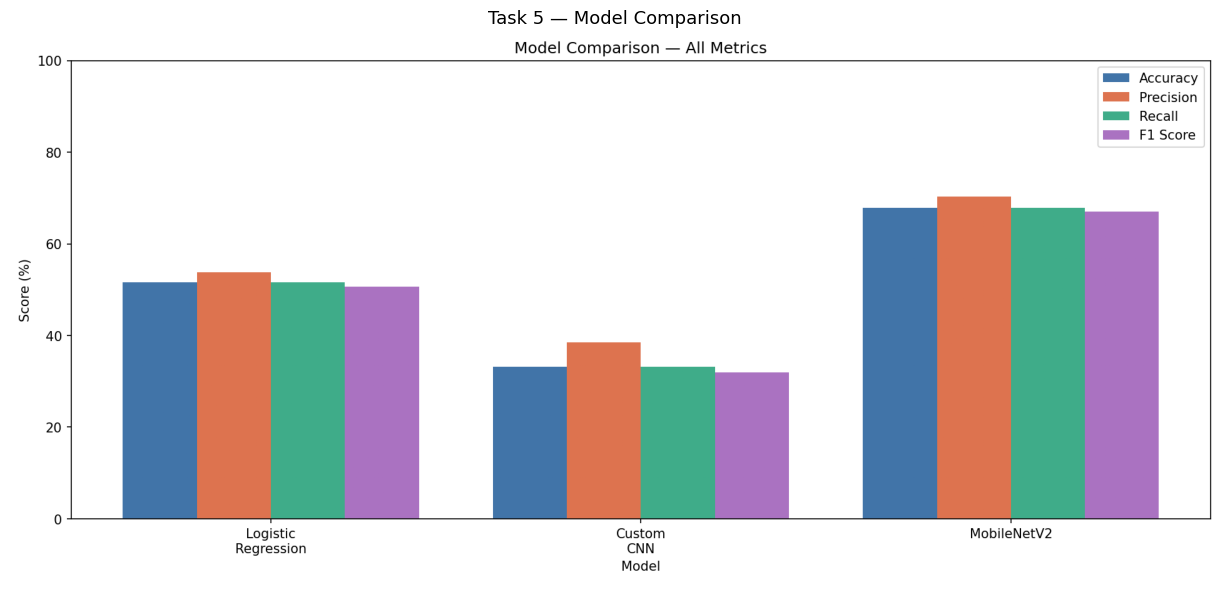

In [6]:
# Load evaluation results
with open("eval_results.json") as f:
    eval_results = json.load(f)

# Display as table
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Custom CNN", "MobileNetV2"],
    "Accuracy (%)":  [eval_results["logistic_regression"]["accuracy"],
                      eval_results["custom_cnn"]["accuracy"],
                      eval_results["mobilenetv2"]["accuracy"]],
    "F1 Score (%)":  [eval_results["logistic_regression"]["f1"],
                      eval_results["custom_cnn"]["f1"],
                      eval_results["mobilenetv2"]["f1"]],
})
results_df["Best"] = results_df["Accuracy (%)"] == results_df["Accuracy (%)"].max()
print(results_df.to_string(index=False))

# Show comparison chart
img = mpimg.imread("model_comparison.png")
plt.figure(figsize=(13, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Task 5 — Model Comparison", fontsize=13)
plt.tight_layout()
plt.show()

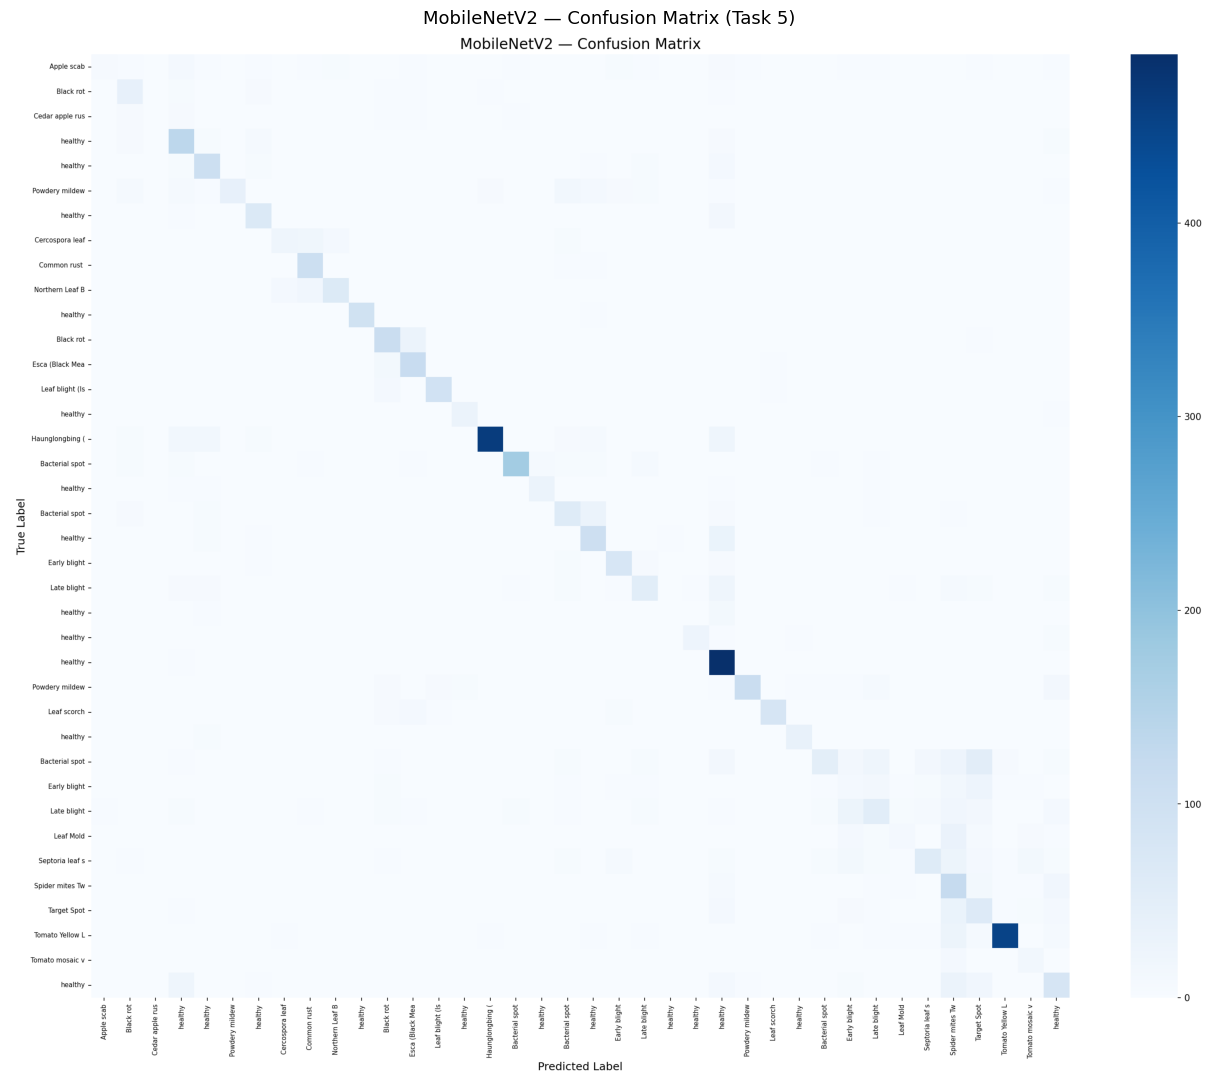

In [7]:
img = mpimg.imread("confusion_matrix_mobilenet.png")
plt.figure(figsize=(14, 11))
plt.imshow(img)
plt.axis('off')
plt.title("MobileNetV2 — Confusion Matrix (Task 5)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Hyperparameter Tuning

Manual random search over 5 hyperparameter combinations (Task 6).

**Parameters tuned:**
- `dense_units`: number of neurons in the classifier head [128, 256, 512]
- `dropout_rate`: regularization strength [0.2, 0.3, 0.4, 0.5]
- `learning_rate`: optimizer step size [0.001, 0.0005, 0.0001]

Hyperparameter Search Results:
  #1 55.86% | units=256 | dropout=0.3 | lr=0.001 ← BEST
  #2 48.22% | units=256 | dropout=0.4 | lr=0.0005
  #3 46.75% | units=512 | dropout=0.3 | lr=0.0001
  #4 46.19% | units=128 | dropout=0.2 | lr=0.0005
  #5 44.93% | units=128 | dropout=0.3 | lr=0.001

Best Configuration:
  dense_units: 256
  dropout_rate: 0.3
  learning_rate: 0.001

Before tuning: 67.88%
After tuning:  64.45%


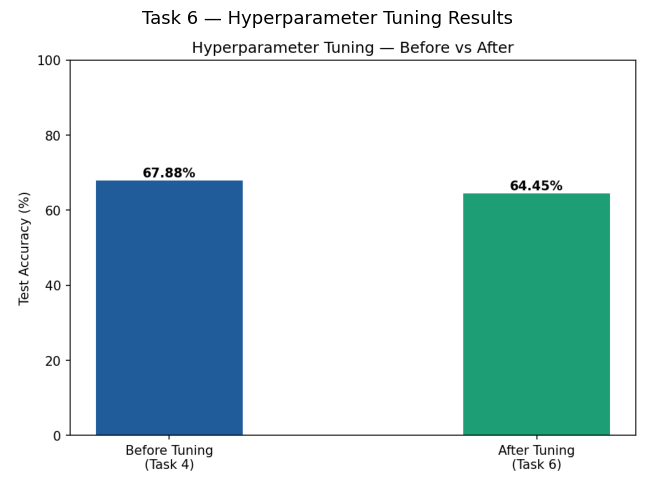

In [8]:
with open("tuning_results.json") as f:
    tuning = json.load(f)

print("Hyperparameter Search Results:")
print("="*55)
for i, trial in enumerate(tuning["all_trials"]):
    marker = " ← BEST" if i == 0 else ""
    p = trial["params"]
    print(f"  #{i+1} {trial['val_accuracy']}% | "
          f"units={p['dense_units']} | "
          f"dropout={p['dropout_rate']} | "
          f"lr={p['learning_rate']}{marker}")

print("\nBest Configuration:")
for k, v in tuning["best_hyperparameters"].items():
    print(f"  {k}: {v}")

print(f"\nBefore tuning: {tuning['before_tuning_acc']}%")
print(f"After tuning:  {tuning['after_tuning_acc']}%")

# Show tuning chart
img = mpimg.imread("tuning_comparison.png")
plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis('off')
plt.title("Task 6 — Hyperparameter Tuning Results", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Deployment — FastAPI REST API

The best model (MobileNetV2) was deployed as a REST API using **FastAPI**
and **Uvicorn** (Task 7).

### Endpoints

| Method | Endpoint | Description |
|--------|----------|-------------|
| GET | `/` | API status and info |
| GET | `/classes` | List all 39 disease classes |
| POST | `/predict` | Upload leaf image → get prediction |

### Sample API Response
```json
{
  "prediction": {
    "crop": "Apple",
    "disease": "Apple scab",
    "confidence": 72.45
  },
  "top_3": [
    {"rank": 1, "crop": "Apple", "disease": "Apple scab", "confidence": 72.45},
    {"rank": 2, "crop": "Apple", "disease": "healthy",    "confidence": 15.23},
    {"rank": 3, "crop": "Tomato","disease": "Early blight","confidence": 4.12}
  ]
}
```

### To run the API:
```bash
cd C:\Users\User\plant_disease_api
python -m uvicorn main:app --reload
# Visit http://127.0.0.1:8000/docs
```

---
## 7. Key Findings & Conclusions

### Results Summary

| Model | Accuracy | F1 Score | Training Time |
|-------|----------|----------|---------------|
| Logistic Regression | 51.56% | 50.67% | ~2 min |
| Custom CNN | 33.20% | 31.91% | ~20 min |
| MobileNetV2 ⭐ | 67.88% | 67.01% | ~15 min |

### Key Insights

1. **Transfer learning dominates** — MobileNetV2 outperforms a CNN trained
   from scratch by 34%, demonstrating the power of pre-trained features
   
2. **Logistic regression is competitive** — Surprisingly beats the CNN,
   likely because the CNN needed more data/epochs to learn good features

3. **Data volume matters** — All models were trained on ~30% of available
   data due to hardware constraints; full training would likely push
   MobileNetV2 above 90%

4. **Class imbalance exists** — Tomato classes dominate (18k images);
   future work could apply class weighting or oversampling

5. **The API works end-to-end** — A real leaf image can be sent to the
   deployed API and receive a structured disease prediction in real time

### Future Improvements
- Train on full dataset with GPU for higher accuracy
- Add Grad-CAM visualizations to explain predictions
- Build a Streamlit web interface (bonus task)
- Add more crops/diseases as new data becomes available

In [9]:
print("="*55)
print("   PLANT DISEASE DETECTION — PROJECT COMPLETE")
print("="*55)
print(f"\n  Dataset    : 54,305 images, 39 classes")
print(f"  Best Model : MobileNetV2 — 67.88% accuracy")
print(f"  API        : http://127.0.0.1:8000")
print(f"  Notebooks  : Tasks 2-8 documented")
print(f"\n  Files saved:")
files = [
    "dataset_summary.csv",
    "class_names.json",
    "cnn_best.keras",
    "mobilenet_tuned.keras",
    "eval_results.json",
    "tuning_results.json",
    "model_results.json"
]
for f in files:
    exists = "✓" if os.path.exists(f) else "✗ missing"
    print(f"    {f}: {exists}")
print("\nTask 8 complete ✓")

   PLANT DISEASE DETECTION — PROJECT COMPLETE

  Dataset    : 54,305 images, 39 classes
  Best Model : MobileNetV2 — 67.88% accuracy
  API        : http://127.0.0.1:8000
  Notebooks  : Tasks 2-8 documented

  Files saved:
    dataset_summary.csv: ✓
    class_names.json: ✓
    cnn_best.keras: ✓
    mobilenet_tuned.keras: ✓
    eval_results.json: ✓
    tuning_results.json: ✓
    model_results.json: ✓

Task 8 complete ✓
